### Load data

In [37]:
import kagglehub
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("mosapabdelghany/medical-insurance-cost-dataset")


df = pd.read_csv(path + "/insurance.csv")

Using Colab cache for faster access to the 'medical-insurance-cost-dataset' dataset.


### Initial Exploration (EDA)

In [38]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [102]:
df.shape

(1338, 7)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [41]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [103]:
print('Missing values:\n', df.isnull().sum())

Missing values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


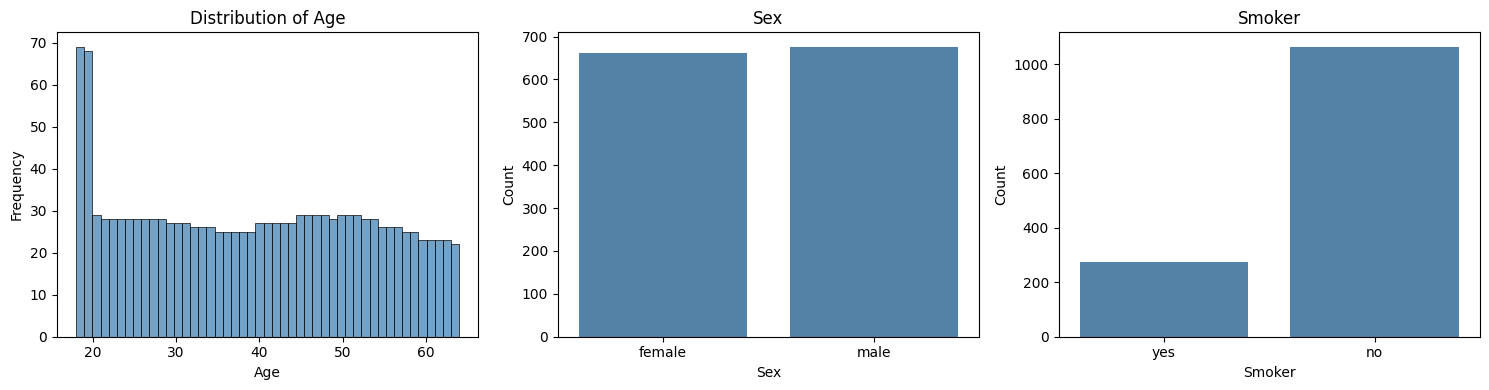

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df['age'], bins=df['age'].nunique(), color='steelblue', ax=axes[0])
axes[0].set(title='Distribution of Age', xlabel='Age', ylabel='Frequency')

sns.countplot(x='sex', data=df, color='steelblue', ax=axes[1])
axes[1].set(title='Sex', xlabel='Sex', ylabel='Count')

sns.countplot(x='smoker', data=df, color='steelblue', ax=axes[2])
axes[2].set(title='Smoker', xlabel='Smoker', ylabel='Count')

plt.tight_layout()
plt.show()

### Data Cleaning

In [43]:
df1 = df.drop(['children','region'], axis='columns')
df1

,age,sex,bmi,smoker,charges
0,19,female,27.900,yes,16884.92400
1,18,male,33.770,no,1725.55230
2,28,male,33.000,no,4449.46200
3,33,male,22.705,no,21984.47061
4,32,male,28.880,no,3866.85520
...,...,...,...,...,...
1333,50,male,30.970,no,10600.54830
1334,18,female,31.920,no,2205.98080
1335,18,female,36.850,no,1629.83350
1336,21,female,25.800,no,2007.94500


In [47]:
df2 = df1[(df1['bmi'] >= 18.5) & (df1['bmi'] <= 40)]
df2['bmi'].describe()

,bmi
count,1227.000000
mean,29.954242
std,5.016693
min,18.500000
25%,26.152500
50%,30.020000
75%,33.712500
max,39.995000


In [48]:
df2.duplicated().sum()

np.int64(1)

In [49]:
df2 = df2.drop_duplicates()
df2.shape

(1226, 5)

In [107]:
print('sex:', df2['sex'].unique(), '| smoker:', df2['smoker'].unique())

sex: ['female' 'male'] | smoker: ['yes' 'no']


In [52]:
df2['charges'].describe()

,charges
count,1226.000000
mean,13091.143068
std,11720.345245
min,1121.873900
25%,4746.521225
50%,9303.297725
75%,16746.657400
max,62592.873090


In [53]:
df2['charges'].sort_values()

,charges
940,1121.87390
808,1131.50660
1244,1135.94070
663,1136.39940
22,1137.01100
...,...
1146,52590.82939
819,55135.40209
577,58571.07448
1230,60021.39897


In [54]:
# Log transform to address skew
import numpy as np

df2['log_charges'] = np.log(df2['charges'])
df2['log_charges'].describe()

,log_charges
count,1226.000000
mean,9.096451
std,0.907946
min,7.022756
25%,8.465167
50%,9.138124
75%,9.725949
max,11.044407


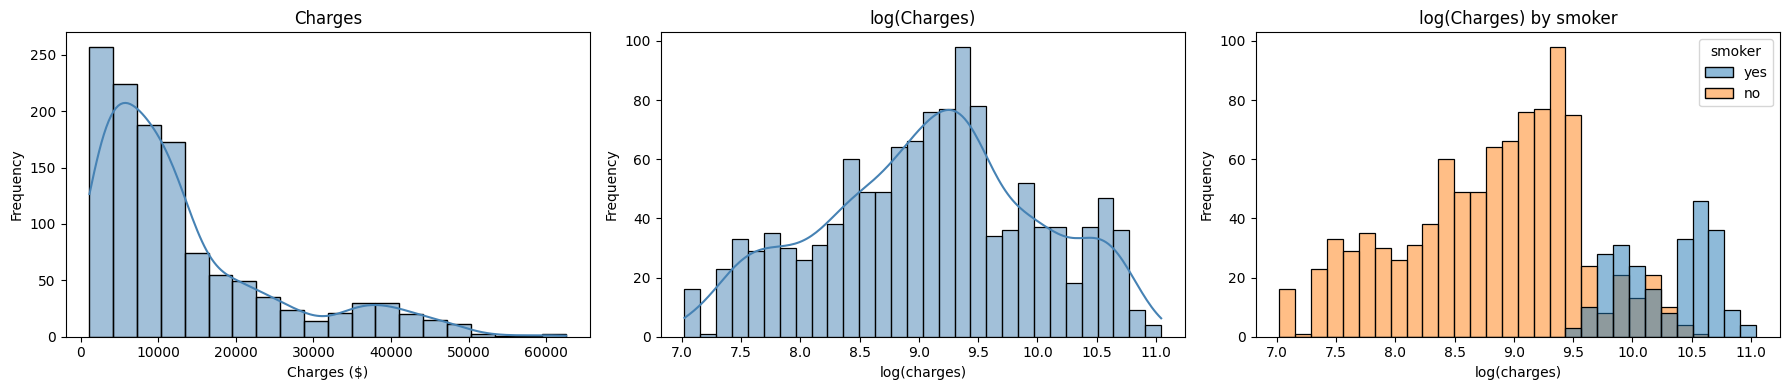

In [109]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.histplot(df2['charges'], bins=20, kde=True, color='steelblue', ax=axes[0])
axes[0].set(title='Charges', xlabel='Charges ($)', ylabel='Frequency')

sns.histplot(df2['log_charges'], bins=30, kde=True, color='steelblue', ax=axes[1])
axes[1].set(title='log(Charges)', xlabel='log(charges)', ylabel='Frequency')

sns.histplot(data=df2, x='log_charges', hue='smoker', bins=30, ax=axes[2])
axes[2].set(title='log(Charges) by smoker', xlabel='log(charges)', ylabel='Frequency')

plt.tight_layout()
plt.show()

### Feature Engineering & Preprocessing

In [57]:
df3 = df2.copy()

In [58]:
df3['sex'] = df3['sex'].map({'female': 0, 'male': 1})
df3['smoker'] = df3['smoker'].map({'no': 0, 'yes': 1})
df3.head()

,age,sex,bmi,smoker,charges,log_charges
0,19,0,27.900,1,16884.92400,9.734176
1,18,1,33.770,0,1725.55230,7.453302
2,28,1,33.000,0,4449.46200,8.400538
3,33,1,22.705,0,21984.47061,9.998092
4,32,1,28.880,0,3866.85520,8.260197


In [60]:
X = df3[['age', 'sex', 'bmi', 'smoker']]
y = df3['log_charges']

### Train/Test Split

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

### Model Comparison

In [110]:
from sklearn.model_selection import GridSearchCV, ShuffleSplit, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

In [111]:
pd.set_option('display.max_colwidth', None)
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)

In [112]:
ALGOS = {
    'linear_regression': {
        'model': LinearRegression(),
        'params': {},
    },
    'lasso': {
        'model': Pipeline([('scale', StandardScaler()), ('model', Lasso())]),
        'params': {'model__alpha': [0.0001, 0.001, 0.01, 0.1]},
    },
    'decision_tree': {
        'model': DecisionTreeRegressor(random_state=0),
        'params': {'max_depth': [2, 3, 4, 5, 7], 'min_samples_leaf': [5, 10, 20]},
    },
    'random_forest': {
        'model': RandomForestRegressor(random_state=0),
        'params': {'n_estimators': [100, 200], 'max_depth': [2, 3, 4, 5], 'min_samples_leaf': [5, 10]},
    },
    'gradient_boosting': {
        'model': GradientBoostingRegressor(random_state=0),
        'params': {
            'n_estimators': [100, 200],
            'learning_rate': [0.03, 0.1],
            'max_depth': [2, 3],
            'min_samples_leaf': [10, 20],
        },
    },
    'svr': {
        'model': Pipeline([('scale', StandardScaler()), ('model', SVR())]),
        'params': {'model__kernel': ['linear', 'rbf'], 'model__C': [1, 10, 20]},
    },
}

In [113]:
def find_best_model(X, y, cv=cv):
    rows = []
    for name, cfg in ALGOS.items():
        gs = GridSearchCV(cfg['model'], cfg['params'], cv=cv)
        gs.fit(X, y)
        rows.append({'model': name, 'best_score': gs.best_score_, 'best_params': gs.best_params_})
    return pd.DataFrame(rows)

In [114]:
find_best_model(X_train, y_train)

,model,best_score,best_params
0,linear_regression,0.704143,{}
1,lasso,0.705223,{'model__alpha': 0.01}
2,decision_tree,0.760304,"{'max_depth': 5, 'min_samples_leaf': 20}"
3,random_forest,0.766695,"{'max_depth': 4, 'min_samples_leaf': 10, 'n_estimators': 200}"
4,gradient_boosting,0.769399,"{'learning_rate': 0.03, 'max_depth': 3, 'min_samples_leaf': 20, 'n_estimators': 100}"
5,svr,0.752937,"{'model__C': 1, 'model__kernel': 'rbf'}"


In [115]:
# Does an explicit smoker x obesity interaction help a linear model?
X_train_int = X_train.assign(obese=(X_train['bmi'] >= 30).astype(int))
X_train_int['smoker_obese'] = X_train_int['smoker'] * X_train_int['obese']

baseline = cross_val_score(LinearRegression(), X_train, y_train, cv=cv).mean()
with_interaction = cross_val_score(LinearRegression(), X_train_int, y_train, cv=cv).mean()
print(f'Linear CV R2: {baseline:.3f} -> {with_interaction:.3f} with interaction features')

Linear CV R2: 0.704 -> 0.723 with interaction features


### Final Model Evaluation

In [116]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

BEST_PARAMS = dict(learning_rate=0.03, max_depth=3, min_samples_leaf=20, n_estimators=100, random_state=0)


def dollar_metrics(y_true_log, pred_log):
    actual, pred = np.exp(y_true_log), np.exp(pred_log)
    return {
        'R2': r2_score(actual, pred),
        'RMSE ($)': np.sqrt(mean_squared_error(actual, pred)),
        'MAE ($)': mean_absolute_error(actual, pred),
    }

In [117]:
models = {
    'constant baseline': DummyRegressor(),
    'linear regression': LinearRegression(),
    'gradient boosting': GradientBoostingRegressor(**BEST_PARAMS),
}

results = {}
for name, m in models.items():
    m.fit(X_train, y_train)
    results[name] = dollar_metrics(y_test, m.predict(X_test))

final = models['gradient boosting']
print('Gradient boosting R2 on log scale:', round(r2_score(y_test, final.predict(X_test)), 3))
pd.DataFrame(results).T.round(2)

Gradient boosting R2 on log scale: 0.837


,R2,RMSE ($),MAE ($)
constant baseline,-0.12,12164.58,7917.30
linear regression,0.49,8220.34,4175.26
gradient boosting,0.85,4398.87,2131.10


### Save Model & Predict Function

In [121]:
import pickle

final_all = GradientBoostingRegressor(**BEST_PARAMS).fit(X, y)

with open('insurance_model.pkl', 'wb') as f:
    pickle.dump(final_all, f)

In [122]:
import json

columns = {'data_columns': [col.lower() for col in X.columns]}

with open('columns.json', 'w') as f:
    f.write(json.dumps(columns))